In [5]:
import cv2
import os
import random
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
train_dir = 'classify-v2-dataset/train/'
test_dir = 'classify-v2-dataset/valid/'

In [3]:
def removemulticlass(classnames: list[str]):
    res = []
    for i, classname in enumerate(classnames):
        # print(i)
        a = classname.split(' ')
        # print(len(a))
        if len(a) == 1:
            res+=a
    return res

def getcountfrommulticlass(classname: str, listdir: list[str]):
    count = 0
    for i in listdir:
        if classname in i and classname!=i and len(i.split(' '))>1:
            count += len(os.listdir(os.path.join(train_dir, i)))
    return count

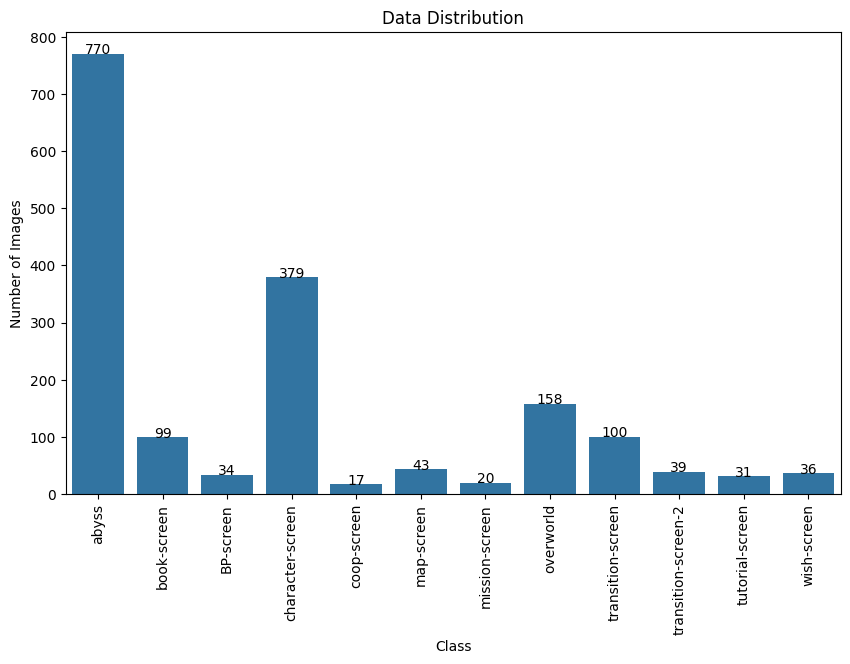

In [4]:
# Get the list of classes
classes = os.listdir(train_dir)
classes = removemulticlass(classes)

# Count the number of images in each class
class_counts = {class_name:getcountfrommulticlass(class_name, os.listdir(train_dir)) + len(os.listdir(os.path.join(train_dir, class_name))) for class_name in classes}
class_counts_df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
# Plot the count plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Class', y='Count', data=class_counts_df)
plt.title('Data Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=90)
# Annotate each bar with the count value
for index, row in class_counts_df.iterrows():
    ax.text(index, row['Count'], row['Count'], color='black', ha="center")
plt.show()


In [96]:
UPSAMPLETARGET = 379
upsampletarget = 'wish-screen'
class_train_dir = os.path.join('classify-v2-dataset-upsample\\train\\', upsampletarget)
class_train_files = [f for f in os.listdir(class_train_dir) if os.path.isfile(os.path.join(class_train_dir, f))]
current_samples = len(class_train_files)

# Determine the number of samples to add for upsampling
samples_to_add = UPSAMPLETARGET - current_samples
for classitem in upsampletarget:
    # Randomly select existing images from the class to duplicate
    for i in range(samples_to_add):
        # Choose a random image file
        random_image = random.choice(class_train_files)
        
        # Open the image
        image_path = os.path.join(class_train_dir, random_image)
        image = cv2.imread(image_path)
        # print(image.shape, image_path)
        
        # Apply transformations (e.g., blur, grayscale)
        transformation = random.choice(['blur', 'grayscale','bilateral','saturation', 'none'])
        if transformation == 'blur':
            image = cv2.GaussianBlur(image, (5,5), 0)
        elif transformation == 'grayscale':
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        elif transformation == 'bilateral':
            image = cv2.bilateralFilter(image,9,75,75)
        elif transformation == 'saturation':
            image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
            saturation_change = random.choice([0.25,-0.25])
            image[:, :, 1] = np.clip(image[:, :, 1] + image[:, :, 1] * saturation_change, 0, 255)
            image = cv2.cvtColor(image, cv2.COLOR_HSV2BGR)
        
        # Generate a new file name
        new_filename = f"{current_samples + i}_{classitem}.png"
        new_image_path = os.path.join(class_train_dir, new_filename)
        
        # Save the transformed image
        cv2.imwrite(new_image_path, image)
    updated_class_train_files = [f for f in os.listdir(class_train_dir) if os.path.isfile(os.path.join(class_train_dir, f))]
    print(f"Number of samples in {classitem} class after upsampling: {len(updated_class_train_files)}")

Number of samples in wish-screen class after upsampling: 301


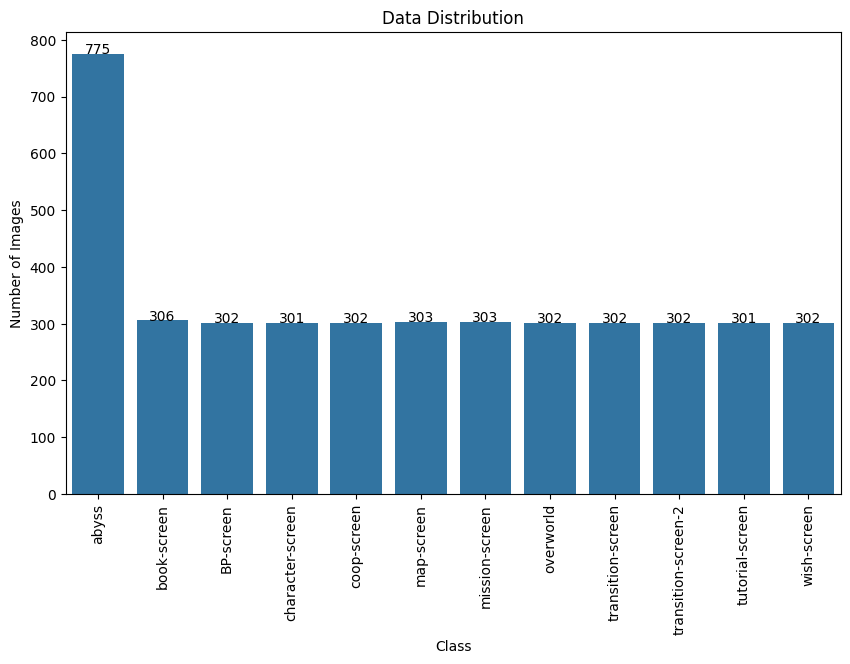

In [97]:
# Get the list of classes
classes = os.listdir(train_dir)
classes = removemulticlass(classes)

# Count the number of images in each class
class_counts = {class_name:getcountfrommulticlass(class_name, os.listdir(train_dir)) + len(os.listdir(os.path.join(train_dir, class_name))) for class_name in classes}
class_counts_df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
# Plot the count plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Class', y='Count', data=class_counts_df)
plt.title('Data Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=90)
# Annotate each bar with the count value
for index, row in class_counts_df.iterrows():
    ax.text(index, row['Count'], row['Count'], color='black', ha="center")
plt.show()
